In [1]:
# Uncomment if needed
# !pip install onnxruntime numpy matplotlib seaborn scikit-learn pillow tqdm

import os
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [2]:
# ==========================
# CONFIGURATION
# ==========================

hackathon_dataset_path = r"D:\Phase_2\hackathon_test_dataset"   # 🔁 CHANGE THIS
onnx_model_path = r"D:\Phase_2\defect_classification_mobilenet_improved.onnx"
label_encoder_path = r"D:\Phase_2\label_encoder_mobilenet_improved.pkl"

categories = ['bridge', 'clean', 'CMP(scratch)', 'cracks',
              'LER', 'open', 'others','particles', 'vias']

IMG_SIZE = 224

print("="*60)
print("📂 PHASE 2 CONFIGURATION")
print("="*60)
print("Dataset:", hackathon_dataset_path)
print("ONNX Model:", onnx_model_path)
print("Classes:", categories)
print("="*60)


📂 PHASE 2 CONFIGURATION
Dataset: D:\Phase_2\hackathon_test_dataset
ONNX Model: D:\Phase_2\defect_classification_mobilenet_improved.onnx
Classes: ['bridge', 'clean', 'CMP(scratch)', 'cracks', 'LER', 'open', 'others', 'particles', 'vias']


In [3]:
print("🔄 Loading ONNX model...")
session = ort.InferenceSession(onnx_model_path)

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print("✅ ONNX model loaded successfully")


🔄 Loading ONNX model...
✅ ONNX model loaded successfully


In [4]:
# Preferred: Load saved encoder
if os.path.exists(label_encoder_path):
    with open(label_encoder_path, "rb") as f:
        label_encoder = pickle.load(f)
    print("✅ Loaded saved label encoder")
else:
    # Fallback (must match Phase-1)
    label_encoder = LabelEncoder()
    label_encoder.fit(categories)
    print("⚠️ Label encoder recreated manually")

class_names = label_encoder.classes_
print("Model Classes:", class_names)


✅ Loaded saved label encoder
Model Classes: ['CMP(scratch)' 'LER' 'bridge' 'clean' 'cracks' 'open' 'others' 'vias']


In [5]:
import numpy as np
from PIL import Image

# ===== EXACT SAME VALUES USED IN TRAINING =====
IMG_SIZE = 224

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_image(img_path):
    # 1️⃣ Load image (NO RGB conversion here)
    image = Image.open(img_path)

    # 2️⃣ Resize (same as transforms.Resize)
    image = image.resize((IMG_SIZE, IMG_SIZE))
    

    # 3️⃣ Convert to grayscale (same as Grayscale(num_output_channels=3))
    image = image.convert("L")

    # 4️⃣ Convert to numpy and scale to [0,1] (same as ToTensor())
    image = np.array(image, dtype=np.float32) / 255.0

    # 5️⃣ Replicate grayscale → 3 channels
    image = np.stack([image, image, image], axis=-1)

    # 6️⃣ Normalize using ImageNet stats (same as Normalize)
    image = (image - MEAN) / STD

    # 7️⃣ Convert HWC → CHW (PyTorch format)
    image = np.transpose(image, (2, 0, 1))

    # 8️⃣ Add batch dimension
    image = np.expand_dims(image, axis=0)

    # 9️⃣ Ensure float32 for ONNX
    image = image.astype(np.float32)

    return image


In [6]:
image_paths = []
true_labels_raw = []

for class_name in os.listdir(hackathon_dataset_path):
    class_path = os.path.join(hackathon_dataset_path, class_name)
    
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                image_paths.append(os.path.join(class_path, img_file))
                true_labels_raw.append(class_name)

print("Total Hackathon Test Images:", len(image_paths))


Total Hackathon Test Images: 296


In [7]:
test_tensor = preprocess_image(image_paths[0])

print("Shape:", test_tensor.shape)
print("Dtype:", test_tensor.dtype)
print("Min value:", test_tensor.min())
print("Max value:", test_tensor.max())


Shape: (1, 3, 224, 224)
Dtype: float32
Min value: -1.9637812
Max value: 2.64


In [8]:
mapped_labels = []

for label in true_labels_raw:
    if label in label_encoder.classes_:
        mapped_labels.append(label)
    else:
        mapped_labels.append("others")  # map unknown class to "others"

true_labels = label_encoder.transform(mapped_labels)


In [9]:

import scipy.special

predictions = []

others_index = label_encoder.transform(["others"])[0]

THRESHOLD = 0.42  # Try 0.50–0.65

print("🚀 Running inference with threshold for 'others'...")

for img_path in tqdm(image_paths):

    input_tensor = preprocess_image(img_path)

    outputs = session.run(
        [output_name],
        {input_name: input_tensor}
    )

    logits = outputs[0][0]
    probs = scipy.special.softmax(logits)

    max_prob = np.max(probs)
    pred_class = np.argmax(probs)

    if max_prob < THRESHOLD:
        pred_class = others_index

    predictions.append(pred_class)

predictions = np.array(predictions)

print("✅ Inference completed")



🚀 Running inference with threshold for 'others'...


100%|██████████| 296/296 [00:01<00:00, 265.67it/s]

✅ Inference completed


In [10]:
print("="*60)
print("📊 PHASE 2 TEST METRICS")
print("="*60)

print(classification_report(
    true_labels,
    predictions,
    target_names=class_names,
    digits=4
))

accuracy = (predictions == true_labels).mean() * 100
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, predictions, average='macro', zero_division=0
)

print(f"\nOverall Accuracy: {accuracy:.2f}%")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1-Score:  {f1_macro:.4f}")


📊 PHASE 2 TEST METRICS
              precision    recall  f1-score   support

CMP(scratch)     0.5385    0.4667    0.5000        30
         LER     0.5833    0.2333    0.3333        30
      bridge     0.3333    0.6250    0.4348        32
       clean     0.5294    0.2727    0.3600        33
      cracks     0.7917    0.6129    0.6909        31
        open     0.2121    0.2333    0.2222        30
      others     0.4123    0.5875    0.4845        80
        vias     0.7000    0.2333    0.3500        30

    accuracy                         0.4392       296
   macro avg     0.5126    0.4081    0.4220       296
weighted avg     0.4955    0.4392    0.4329       296


Overall Accuracy: 43.92%
Macro Precision: 0.5126
Macro Recall:    0.4081
Macro F1-Score:  0.4220


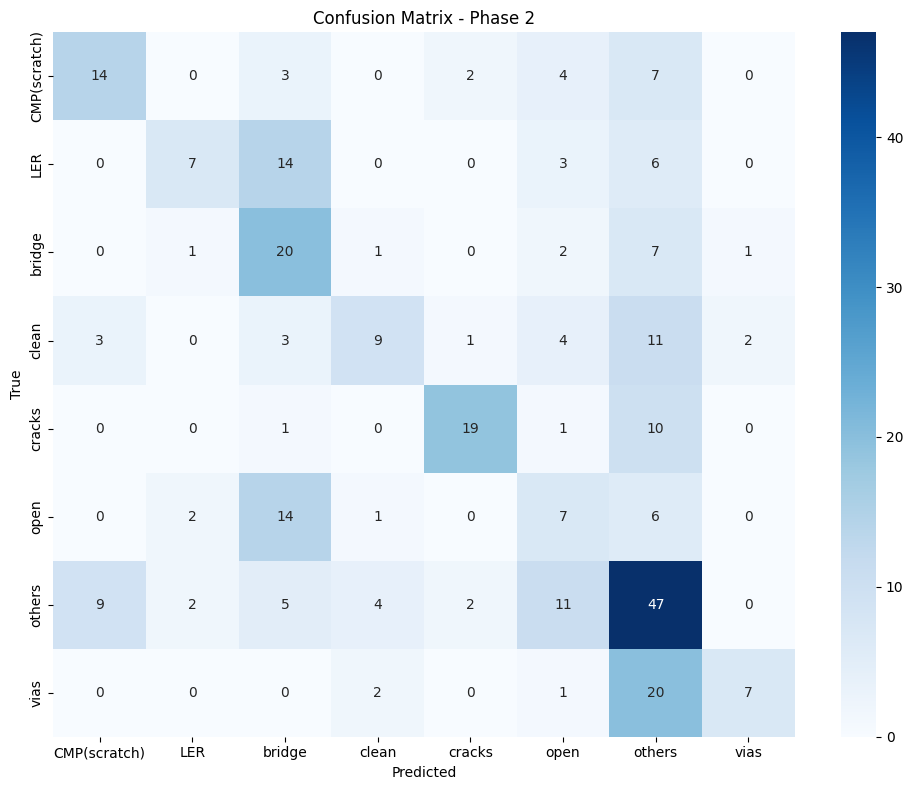

In [11]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Phase 2")
plt.tight_layout()
plt.show()


In [12]:
# ======================================================
# PHASE 2 SUBMISSION LOG GENERATOR (COMPLETE)
# ======================================================

import sys
import os
import datetime
import numpy as np
import onnxruntime as ort
from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix, accuracy_score

# Output file name
log_file_path = "phase2_prediction_log.txt"

# 1. Map Notebook Variables
y_pred_log = predictions   # From your inference loop
y_true_log = true_labels   # From your label encoder transformation

# 2. Calculate Strict Metrics
acc_score = accuracy_score(y_true_log, y_pred_log)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true_log, y_pred_log, average='macro', zero_division=0
)

# 3. Generate the Log File
with open(log_file_path, "w", encoding="utf-8") as f:
    
    def log(text):
        print(text)      # Print to Jupyter Console
        f.write(text + "\n") # Write to File

    # --- HEADER ---
    log("="*80)
    log("DEEPTECH HACKATHON 2026 - PHASE 2 INFERENCE LOG")
    log("="*80)
    log(f"Date & Time    : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log(f"Idea ID        : 268")
    log(f"Team Name      : EdgeIntel")
    log(f"Team Leader    : Harshvardhan Bharat Mali")
    log("-" * 80)

    # --- SUBMISSION ENVIRONMENT ---
    log("\n[ENVIRONMENT]")
    log(f"Python Version : {sys.version.split()[0]}")
    log(f"ONNX Runtime   : {ort.__version__}")
    log(f"NumPy Version  : {np.__version__}")

    # --- MODEL & DATA DETAILS ---
    onnx_name = os.path.basename(onnx_model_path) if 'onnx_model_path' in globals() else "Unknown"
    dataset_name = os.path.basename(hackathon_dataset_path) if 'hackathon_dataset_path' in globals() else "Unknown"

    log("\n[CONFIGURATION]")
    log(f"Model File     : {onnx_name}")
    log(f"Dataset Folder : {dataset_name}")
    log(f"Input Size     : {IMG_SIZE}x{IMG_SIZE}")
    log(f"Total Samples  : {len(y_pred_log)}")
    log(f"Classes        : {list(class_names)}")

    # --- KEY METRICS ---
    log("\n[FINAL RESULTS]")
    log("-" * 80)
    log(f"Accuracy        : {acc_score:.5f}")
    log(f"Precision (Macro): {prec_macro:.5f}")
    log(f"Recall (Macro)   : {rec_macro:.5f}")
    log("-" * 80)

    # --- CLASSIFICATION REPORT ---
    log("\n[DETAILED CLASSIFICATION REPORT]")
    log(classification_report(y_true_log, y_pred_log, target_names=class_names, digits=4))

    # --- CONFUSION MATRIX ---
    log("\n[CONFUSION MATRIX]")
    cm = confusion_matrix(y_true_log, y_pred_log)
    log(str(cm))
    
    # --- DETAILED PREDICTIONS (PER IMAGE) ---
    log("\n" + "="*80)
    log("[DETAILED PREDICTIONS PER IMAGE]")
    log("="*80)
    log(f"{'Image Name':<40} | {'True Label':<15} | {'Predicted':<15} | {'Status'}")
    log("-" * 85)

    for i, path in enumerate(image_paths):
        # decode labels
        true_lbl = class_names[true_labels[i]]
        pred_lbl = class_names[predictions[i]]
        
        # status
        status = "CORRECT" if true_labels[i] == predictions[i] else "WRONG"
        
        # get filename
        fname = os.path.basename(path)
        
        # write line
        log(f"{fname:<40} | {true_lbl:<15} | {pred_lbl:<15} | {status}")

    log("="*80)
    log("END OF LOG")

print(f"\n✅ Log file generated: {os.path.abspath(log_file_path)}")

DEEPTECH HACKATHON 2026 - PHASE 2 INFERENCE LOG
Date & Time    : 2026-02-16 20:32:44
Idea ID        : 268
Team Name      : EdgeIntel
Team Leader    : Harshvardhan Bharat Mali
--------------------------------------------------------------------------------

[ENVIRONMENT]
Python Version : 3.12.0
ONNX Runtime   : 1.24.1
NumPy Version  : 2.3.5

[CONFIGURATION]
Model File     : defect_classification_mobilenet_improved.onnx
Dataset Folder : hackathon_test_dataset
Input Size     : 224x224
Total Samples  : 296
Classes        : [np.str_('CMP(scratch)'), np.str_('LER'), np.str_('bridge'), np.str_('clean'), np.str_('cracks'), np.str_('open'), np.str_('others'), np.str_('vias')]

[FINAL RESULTS]
--------------------------------------------------------------------------------
Accuracy        : 0.43919
Precision (Macro): 0.51258
Recall (Macro)   : 0.40810
--------------------------------------------------------------------------------

[DETAILED CLASSIFICATION REPORT]
              precision    reca